# LangGraph Revision


In [ ]:
import os
import warnings
from pathlib import Path
from typing import Annotated, Any, Literal, TypedDict

# Standard imports
import numpy as np
import pandas as pd
import polars as pl

# Visualization
# import matplotlib.pyplot as plt

# NumPy settings
np.set_printoptions(precision=4)

# Pandas settings
pd.options.display.max_rows = 1_000
pd.options.display.max_columns = 1_000
pd.options.display.max_colwidth = 600

# Polars settings
pl.Config.set_fmt_str_lengths(1_000)
pl.Config.set_tbl_cols(n=1_000)
pl.Config.set_tbl_rows(n=200)

warnings.filterwarnings("ignore")

# Black code formatter (Optional)
%load_ext lab_black

# auto reload imports
%load_ext autoreload
%autoreload 2

In [2]:
from rich.console import Console
from rich.theme import Theme

custom_theme = Theme(
    {
        "white": "#FFFFFF",  # Bright white
        "info": "#00FF00",  # Bright green
        "warning": "#FFD700",  # Bright gold
        "error": "#FF1493",  # Deep pink
        "success": "#00FFFF",  # Cyan
        "highlight": "#FF4500",  # Orange-red
    }
)
console = Console(theme=custom_theme)


def create_path(path: str | Path) -> None:
    """
    Create parent directories for the given path if they don't exist.

    Parameters
    ----------
    path : str | Path
        The file path for which to create parent directories.
    """
    # Convert to Path object if it's a string
    path_obj: Path = Path(path) if isinstance(path, str) else path

    # Get the parent directory and create it if it doesn't exist
    path_obj.parent.mkdir(parents=True, exist_ok=True)


def go_up_from_current_directory(*, go_up: int = 1) -> None:
    """This is used to up a number of directories.

    Params:
    -------
    go_up: int, default=1
        This indicates the number of times to go back up from the current directory.

    Returns:
    --------
    None
    """
    import sys

    CONST: str = "../"
    NUM: str = CONST * go_up

    # Goto the previous directory
    prev_directory = os.path.join(os.path.dirname(__name__), NUM)
    # Get the 'absolute path' of the previous directory
    abs_path_prev_directory = os.path.abspath(prev_directory)

    # Add the path to the System paths
    sys.path.insert(0, abs_path_prev_directory)
    print(abs_path_prev_directory)

In [3]:
go_up_from_current_directory(go_up=2)

from model_config import LocalModel, RemoteModel  # noqa: E402
from settings import refresh_settings  # noqa: E402

settings = refresh_settings()

/Users/mac/Desktop/Projects/RAG-Tutorials


In [4]:
from langchain_openai import ChatOpenAI

model_str_remote: str = RemoteModel.MISTRAL_SMALL_3_2_24B_INSTRUCT
model_str2_remote: str = RemoteModel.QWEN3_30B_A3B
model_str_local: str = LocalModel.MISTRAL_7B_INSTRUCT_V0_3_Q4_0

remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=model_str_remote,
)
remote_llm_with_tools = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=model_str2_remote,
)

local_llm = ChatOpenAI(
    api_key=settings.OLLAMA_API_KEY.get_secret_value(),
    base_url=settings.OLLAMA_URL,
    temperature=0.0,
    model=model_str_local,
)

In [5]:
from langchain_community.utilities import GoogleSerperAPIWrapper

search = GoogleSerperAPIWrapper(k=2)
# search.run("What is LangGraph?")

In [6]:
# results = search.results("What is LangGraph?")
# console.print(results)

In [7]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool


@tool
def add(a: float, b: float) -> float:
    """Add two float."""
    return a + b


@tool
def multiply(a: float, b: float) -> float:
    """Multiply two float."""
    return a * b


llm_with_tools = local_llm.bind_tools([add, multiply])

query: str = "What is the addition of 2 and 7?"
response = llm_with_tools.invoke(query)
console.print(response)

AIMessage(
    content='',
    additional_kwargs={
        'tool_calls': [
            {
                'id': 'call_mulo3yn0',
                'function': {'arguments': '{"a":2,"b":7}', 'name': 'add'},
                'type': 'function',
                'index': 0
            }
        ],
        'refusal': None
    },
    response_metadata={
        'token_usage': {
            'completion_tokens': 79,
            'prompt_tokens': 146,
            'total_tokens': 225,
            'completion_tokens_details': None,
            'prompt_tokens_details': None
        },
        'model_name': 'mistral:7b-instruct-v0.3-q4_0',
        'system_fingerprint': 'fp_ollama',
        'id': 'chatcmpl-119',
        'service_tier': None,
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='run--a720c104-cee8-45ed-8318-718b54566602-0',
    tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 7}, 'id': 'call_mulo3yn0', 'type': 'tool_call'}],
    usage_metadata={
        'input_tokens': 146,
        'output_tokens': 79,
        'total_tokens': 225,
        'input_token_details': {},
        'output_token_details': {}
    }
)

In [8]:
for call in response.tool_calls:
    if call["name"] == "add":
        result = add.invoke(call["args"])
    elif call["name"] == "multiply":
        result = multiply.invoke(call["args"])
    console.print(f"The result is: {result}")

The result is: 9.0

In [9]:
query: str = "What's the product of 2 and 7?"
response = llm_with_tools.invoke(query)

for call in response.tool_calls:
    if call["name"] == "add":
        result = add.invoke(call["args"])
    elif call["name"] == "multiply":
        result = multiply.invoke(call["args"])
        console.print(f"The result is: {result}")

The result is: 14.0

In [10]:
@tool
def google_search(query: str) -> Any:
    """Perform a Google search and return results."""
    search = GoogleSerperAPIWrapper(k=3)
    return search.results(query)


llm_with_tools = local_llm.bind_tools([add, multiply, google_search])

In [11]:
query: str = "Who won the recently concluded Fifa Club World Cup?"
response = llm_with_tools.invoke(query)

for call in response.tool_calls:
    if call["name"] == "add":
        result = add.invoke(call["args"])
    elif call["name"] == "multiply":
        result = multiply.invoke(call["args"])
    elif call["name"] == "google_search":
        result = google_search.invoke(call["args"])
    console.print(f"The result is: {result}")

The result is: {'searchParameters': {'q': 'Recently concluded Fifa Club World Cup winner', 'gl': 'us', 'hl': 'en', 
'type': 'search', 'num': 3, 'engine': 'google'}, 'organic': [{'title': 'FIFA Club World Cup - Wikipedia', 'link': 
'https://en.wikipedia.org/wiki/FIFA_Club_World_Cup', 'snippet': 'The current world champions are Chelsea, who 
defeated Paris Saint-Germain 3–0 in the 2025 final. FIFA Club World Cup. The FIFA Club World Cup logo used since 
...', 'sitelinks': [{'title': 'Final venue', 'link': 
'https://en.wikipedia.org/wiki/List_of_FIFA_Club_World_Cup_finals'}, {'title': '2018', 'link': 
'https://en.wikipedia.org/wiki/2018_FIFA_Club_World_Cup'}, {'title': '2021 FIFA Club World Cup final', 'link': 
'https://en.wikipedia.org/wiki/2021_FIFA_Club_World_Cup_final'}, {'title': 'FIFA Club World Cup awards', 'link': 
'https://en.wikipedia.org/wiki/FIFA_Club_World_Cup_awards'}], 'position': 1}, {'title': 'Who has won the FIFA Club 
World Cup? Champions by year - ESPN', 'link': 
'https://www.espn.com/soccer/story/_/id/45553032/who-won-fifa-club-world-cup-champions-year', 'snippet': 'Real 
Madrid has won the tournament a record five times, claiming victory in 2014, 2016, 2017, 2018 and 2022.', 'date': 
'Jul 13, 2025', 'position': 2}, {'title': "Chelsea's first title wins | FIFA Club World Cup", 'link': 
'https://www.fifa.com/en/tournaments/mens/club-world-cup/usa-2025/articles/chelsea-first-title-wins', 'snippet': 
"Enzo Maresca's side defeated PSG to claim the inaugural FIFA Club World Cup. Chelsea have now won every major 
competition the club has ...", 'date': 'Jul 15, 2025', 'position': 3}], 'relatedSearches': [{'query': 'fifa club 
world cup winners list'}, {'query': 'fifa club world cup winners list from 1930 to 2023'}, {'query': 'fifa club 
world cup winners list from 1930 to 2018'}, {'query': 'who won the last club world cup'}, {'query': 'who won the 
club world cup most'}, {'query': 'fifa world cup winners list'}, {'query': 'fifa club world cup 2025 qualified 
teams list'}, {'query': 'when was the last club world cup'}], 'credits': 1}

In [12]:
messages = [
    HumanMessage(content=query),
    AIMessage(content=str(result)),
]

res = local_llm.invoke(messages)

In [13]:
console.print(res.content)

The information provided indicates that Chelsea won the recently concluded Fifa Club World Cup in 2025. Is this 
correct?

Yes, according to the search results, Chelsea won the recently concluded Fifa Club World Cup in 2025.

In [14]:
# Without the use of tools
res = local_llm.invoke(query)
console.print(res.content)

The recently concluded FIFA Club World Cup was won by Bayern Munich. They defeated Tigres UANL from Mexico in the 
final match held on February 11, 2020. This was Bayern's first-ever title in this competition.

# Using LangGraph

### Agent Workflow

- A user submits a query.

- The agent determines if a tool is needed or if its internal knowledge is sufficient.

- If a tool is required, the agent executes it with the necessary information, and the result is sent back for the agent to process.

- If no tool is needed, the agent generates a response based on its own knowledge and the user's input.

<br>

[![image.png](https://i.postimg.cc/wMRfT7vF/image.png)](https://postimg.cc/ctZMF1f8)

In [15]:
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    messages: Annotated[list[Any], add_messages]


@tool
def add(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b


@tool
def multiply(a: float, b: float) -> float:
    """Multiply two numbers."""
    return a * b


@tool
def local_wiki(query: str) -> str:
    """Search the local wiki for a query."""
    response: str = """
    Emmanuel Obi is a 28-year-old AI Engineer based in Enugu, Nigeria. He has a keen professional interest in 
    Natural Language Processing (NLP). When he's not working, Emmanuel enjoys a variety of hobbies. He's a big 
    fan of football and a dedicated supporter of his favorite team, Chelsea FC. He also finds time to stay 
    active by working out and unwinds by listening to music. As a young professional, Emmanuel embodies a blend 
    of technical expertise and a vibrant personal life.
    """
    return response


tools = [add, multiply, local_wiki]
llm_with_tools = remote_llm_with_tools.bind_tools(tools)

In [16]:
sys_msg: str = """
<system>
    <role>
    You're a helpful assistant that answers user questions in a concise and informative manner.
    You have access to a variety of tools and resources to assist with answering questions.
    </role>

    <guidlines>
    - Be concise and informative in your responses.
    - Use the available tools and resources to enhance your answers.
    - Maintain a friendly and helpful tone.
    </guidlines>
</system>
"""


system_message = SystemMessage(content=sys_msg)


# Node
def assistant(state: AgentState) -> dict[str, Any]:
    return {"messages": [llm_with_tools.invoke([system_message] + state["messages"])]}


def route_tools(state: AgentState) -> Literal["tools", "__end__"]:
    # Check if state is a list (legacy or alternate format)
    if isinstance(state, list):
        ai_message = state[-1]  # Get the last message (assumed to be AIMessage)
    # Otherwise, try to get messages from the state dictionary
    elif messages := state.get("messages", []):
        ai_message = messages[-1]  # Get the last message (assumed to be AIMessage)
    else:
        # If no messages are found, raise an error for debugging
        raise ValueError(f"No message found in the input state to tool_edge: {state}")

    # If the AI message contains tool calls, route to the "tools" node
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    # Otherwise, end the workflow
    return "__end__"

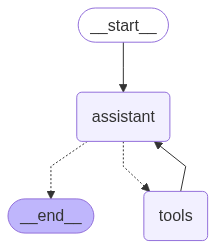

In [17]:
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display


# Graph
builder = StateGraph(AgentState)

# Nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools=tools))

# Edges
builder.add_edge(START, "assistant")
# If the assistant needs to use a tool, route to the tools node
builder.add_conditional_edges("assistant", route_tools)
# If a tool was used, route back to the assistant
builder.add_edge("tools", "assistant")

# Build
react_graph = builder.compile()
# Visualize the graph
display(Image(react_graph.get_graph(xray=1).draw_mermaid_png()))

In [18]:
query: str = "What is the sum of 3 and 9? Multiply the result by 2.5."
messages = [HumanMessage(content=query)]
responses = react_graph.invoke({"messages": messages})

In [19]:
for m in responses["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the sum of 3 and 9? Multiply the result by 2.5.
================================== Ai Message ==================================
Tool Calls:
  add (call_Ps2ID7k796tq23FVv4iuOws7)
 Call ID: call_Ps2ID7k796tq23FVv4iuOws7
  Args:
    a: 3
    b: 9
  multiply (call_zKLVu7OSrr4WntvISBHTZi8a)
 Call ID: call_zKLVu7OSrr4WntvISBHTZi8a
  Args:
    a: 12
    b: 2.5
================================= Tool Message =================================
Name: add

12.0
================================= Tool Message =================================
Name: multiply

30.0
================================== Ai Message ==================================

The final result is 30.0.


In [20]:
query: str = "Who is Emmanuel Obi? How old is he now and how old will he be in 5 years?"
messages = [HumanMessage(content=query)]
responses = react_graph.invoke({"messages": messages})


for m in responses["messages"]:
    m.pretty_print()

================================ Human Message =================================

Who is Emmanuel Obi? How old is he now and how old will he be in 5 years?
================================== Ai Message ==================================
Tool Calls:
  local_wiki (call_Lf0f1VR2ywJKyKyeMfmfaIhc)
 Call ID: call_Lf0f1VR2ywJKyKyeMfmfaIhc
  Args:
    query: Emmanuel Obi
================================= Tool Message =================================
Name: local_wiki


    Emmanuel Obi is a 28-year-old AI Engineer based in Enugu, Nigeria. He has a keen professional interest in 
    Natural Language Processing (NLP). When he's not working, Emmanuel enjoys a variety of hobbies. He's a big 
    fan of football and a dedicated supporter of his favorite team, Chelsea FC. He also finds time to stay 
    active by working out and unwinds by listening to music. As a young professional, Emmanuel embodies a blend 
    of technical expertise and a vibrant personal life.
    
=============================

In [21]:
query: str = "What was my first question?"
messages = [HumanMessage(content=query)]
responses = react_graph.invoke({"messages": messages})


for m in responses["messages"]:
    m.pretty_print()

================================ Human Message =================================

What was my first question?
================================== Ai Message ==================================

The assistant does not have access to previous questions or conversation history. This is the first question you've asked in this interaction. Let me know how I can assist you now!


### Add Memory

```py
from langgraph.checkpoint.memory import MemorySaver
```

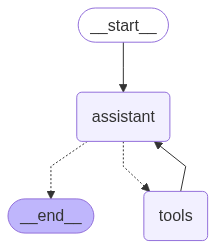

In [50]:
from langgraph.checkpoint.memory import MemorySaver


# Graph
builder = StateGraph(AgentState)

# Nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools=tools))

# Edges
builder.add_edge(START, "assistant")
# If the assistant needs to use a tool, route to the tools node
builder.add_conditional_edges("assistant", route_tools)
# If a tool was used, route back to the assistant
builder.add_edge("tools", "assistant")
builder.add_edge("assistant", END)

# Build
memory = MemorySaver()
react_graph = builder.compile(checkpointer=memory)

# Visualize the graph
display(Image(react_graph.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "1"}}

# 1
query: str = "Hello, I'm Obi Emmanuel. What is the sum of 3 and 9? Multiply the result by 2.5."
# query: str = "Hello, I'm Obi Emmanuel"
messages = [HumanMessage(content=query)]
responses = react_graph.invoke({"messages": messages}, config=config)

for m in responses["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello, I'm Obi Emmanuel. What is the sum of 3 and 9? Multiply the result by 2.5.
================================== Ai Message ==================================
Tool Calls:
  add (call_tlx3uwGiFkwVOR9VJODQNZqF)
 Call ID: call_tlx3uwGiFkwVOR9VJODQNZqF
  Args:
    a: 3
    b: 9
  multiply (call_fR3Y06sPrzBJUX4gOVujAxa8)
 Call ID: call_fR3Y06sPrzBJUX4gOVujAxa8
  Args:
    a: 12
    b: 2.5
================================= Tool Message =================================
Name: add

12.0
================================= Tool Message =================================
Name: multiply

30.0
================================== Ai Message ==================================

The final result is 30.0. 

$$
\boxed{30.0}
$$


In [52]:
# 2
query: str = "What is my name?"

messages = [HumanMessage(content=query)]
responses = react_graph.invoke({"messages": messages}, config=config)

for m in responses["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello, I'm Obi Emmanuel. What is the sum of 3 and 9? Multiply the result by 2.5.
================================== Ai Message ==================================
Tool Calls:
  add (call_tlx3uwGiFkwVOR9VJODQNZqF)
 Call ID: call_tlx3uwGiFkwVOR9VJODQNZqF
  Args:
    a: 3
    b: 9
  multiply (call_fR3Y06sPrzBJUX4gOVujAxa8)
 Call ID: call_fR3Y06sPrzBJUX4gOVujAxa8
  Args:
    a: 12
    b: 2.5
================================= Tool Message =================================
Name: add

12.0
================================= Tool Message =================================
Name: multiply

30.0
================================== Ai Message ==================================

The final result is 30.0. 

$$
\boxed{30.0}
$$
================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

Your name is Obi Em

In [48]:
# View the State
my_state = react_graph.get_state(config=config)
console.print(my_state)

StateSnapshot(
    values={
        'messages': [
            HumanMessage(
                content="Hello, I'm Obi Emmanuel. What is the sum of 3 and 9? Multiply the result by 2.5.",
                additional_kwargs={},
                response_metadata={},
                id='68eee2c1-271d-4ff8-8fe0-a1672274ed17'
            ),
            AIMessage(
                content='',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': None,
                    'model_name': 'qwen/qwen3-30b-a3b',
                    'system_fingerprint': None,
                    'id': 'gen-1755428535-hm5wIwv4LhW6vZppjvIm',
                    'service_tier': None,
                    'finish_reason': 'error',
                    'logprobs': None
                },
                id='run--1e2de694-68a9-4a91-8891-03b56bdda882-0'
            ),
            HumanMessage(
                content='What is my name?',
                additional_kwargs={},
                response_metadata={},
                id='893f1481-b09e-4a55-9c13-1e56771ea28e'
            ),
            AIMessage(
                content='Your name is Obi Emmanuel.',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 180,
                        'prompt_tokens': 409,
                        'total_tokens': 589,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': None
                    },
                    'model_name': 'qwen/qwen3-30b-a3b',
                    'system_fingerprint': None,
                    'id': 'gen-1755428602-3FpPEGsXcTf3Xw8p7rIg',
                    'service_tier': None,
                    'finish_reason': 'stop',
                    'logprobs': None
                },
                id='run--513a08dc-a438-4926-9c8a-28b2d2e174c9-0',
                usage_metadata={
                    'input_tokens': 409,
                    'output_tokens': 180,
                    'total_tokens': 589,
                    'input_token_details': {},
                    'output_token_details': {}
                }
            )
        ]
    },
    next=(),
    config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f07b59c-c2fe-6bc4-8004-2da6534c9d73'
        }
    },
    metadata={'source': 'loop', 'step': 4, 'parents': {}},
    created_at='2025-08-17T11:03:25.648367+00:00',
    parent_config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f07b59c-9e70-6e1a-8003-b5cf9f8973d6'
        }
    },
    tasks=(),
    interrupts=()
)

### Practicing Conditional Logic

In [53]:
class AgentStateWithSummarizer(TypedDict):
    messages: Annotated[list[Any], add_messages]
    summary: str

In [ ]:
from langchain_core.messages import RemoveMessage


generate_summary_sys_msg: str = """
<system>

    <role>
    You are a highly attentive assistant tasked with generating or extending summaries of conversations.
    Your goal is to retain all critical information, including names, entities, facts, and context, while being concise.
    </role>

    <previous_summary>
    {summary}
    </previous_summary>

    <instruction>
    - Carefully review the following messages and update the summary to include all important details, especially names, 
    entities, numbers, and any facts or context that may be relevant for future conversation. 
    - Do NOT omit any information that could help the assistant remember the user's identity, preferences, 
    or prior questions.
    - If the previous summary already contains some information, only add new details from the latest messages.
    </instruction>

    <new_messages>{messages}</new_messages>

    <guidelines>
    - Always preserve names, entities, numbers, and facts.
    - Do not generalize or omit specifics.
    - Make the summary concise but comprehensive.
    - The summary should help the assistant recall the user's context and history.
    </guidelines>
    
</system>
"""

sys_msg_with_context: str = """
<system>

    <role>
    You're a helpful assistant that answers user questions in a concise and informative manner considering the context.
    </role>

    <context> \n\n{context} </context>

    <guidlines>
    - Be concise and informative in your responses.
    - Maintain a friendly and helpful tone.
    </guidlines>

</system>
"""


# Nodes
def chatbot(state: AgentStateWithSummarizer) -> dict[str, Any]:
    summary: str = state.get("summary", "")
    context = sys_msg_with_context.format(context=summary)
    response = remote_llm.invoke([SystemMessage(content=context)] + state["messages"])
    print(f"Summary: {state.get('summary', '')}")
    return {"messages": response}


def summarize_messages(state: AgentStateWithSummarizer) -> dict[str, Any]:
    summary: str = state.get("summary", "")
    sys_msg_summarizer = generate_summary_sys_msg.format(summary=summary, messages=state["messages"])
    response = remote_llm.invoke([SystemMessage(content=sys_msg_summarizer)])
    # Delete all but the last 2 messages
    deleted_msgs = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": deleted_msgs}


# Conditional Node
def should_continue(
    state: AgentStateWithSummarizer,
) -> Literal["summarize_messages", "__end__"]:
    if len(state["messages"]) > 5:
        return "summarize_messages"
    return "__end__"

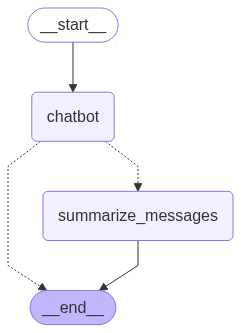

In [111]:
# Graph
builder = StateGraph(AgentState)

# Nodes
builder.add_node("chatbot", chatbot)
builder.add_node("summarize_messages", summarize_messages)

# Edges
builder.add_edge(START, "chatbot")
# If the chatbot needs to use a tool, route to the tools node
builder.add_conditional_edges("chatbot", should_continue)
# If a tool was used, route back to the chatbot
builder.add_edge("chatbot", END)

# Build
memory = MemorySaver()
simple_graph = builder.compile(checkpointer=memory)

# Visualize the graph
display(Image(simple_graph.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "1"}}

# 1
messages: list = [
    HumanMessage(content="Hi, I'm, Neidu"),
    AIMessage(content="Hello, Neidu! How can I assist you today?"),
    HumanMessage(content="What is the weather like today?"),
    AIMessage(content="The weather is sunny with a high of 25°C."),
    HumanMessage(content="Thank you!"),
    AIMessage(content="You're welcome! If you have any more questions, feel free to ask."),
    HumanMessage(content="What do you know about AI agents?"),
]
responses = simple_graph.invoke({"messages": messages}, config=config)

for m in responses["messages"]:
    m.pretty_print()

Summary: 
================================ Human Message =================================

What do you know about AI agents?
================================== Ai Message ==================================

AI agents are software programs that use artificial intelligence to perform tasks, make decisions, or provide services. They can range from simple chatbots to complex systems that automate processes, analyze data, or interact with users in natural language. AI agents can be used in various fields, such as customer service, healthcare, finance, and more. They are designed to learn from data and improve their performance over time.


In [113]:
query: str = "What do you know about me so far? What's my name?"
messages = [HumanMessage(content=query)]
responses = simple_graph.invoke({"messages": messages}, config=config)

for m in responses["messages"]:
    m.pretty_print()

Summary: **Summary:**

- The user introduced themselves as **Neidu**.
- Neidu asked about the **weather today**, and the assistant responded that it is **sunny with a high of 25°C**.
- Neidu then inquired about **AI agents**, and the assistant provided a detailed explanation about their functions, applications, and capabilities.
================================ Human Message =================================

What do you know about AI agents?
================================== Ai Message ==================================

AI agents are software programs that use artificial intelligence to perform tasks, make decisions, or provide services. They can range from simple chatbots to complex systems that automate processes, analyze data, or interact with users in natural language. AI agents can be used in various fields, such as customer service, healthcare, finance, and more. They are designed to learn from data and improve their performance over time.
================================ Huma

In [114]:
query: str = "I'm sure I mentioned my name earlier."
messages = [HumanMessage(content=query)]
responses = simple_graph.invoke({"messages": messages}, config=config)

for m in responses["messages"]:
    m.pretty_print()

Summary: **Summary:**

- The user introduced themselves as **Neidu**.
- Neidu asked about the **weather today**, and the assistant responded that it is **sunny with a high of 25°C**.
- Neidu then inquired about **AI agents**, and the assistant provided a detailed explanation about their functions, applications, and capabilities.
================================ Human Message =================================

I'm sure I mentioned my name earlier.
================================== Ai Message ==================================

You're right, Neidu! You introduced yourself as Neidu earlier in our conversation. How can I assist you today?


In [ ]:
# Utils
import os
from typing import Any, Dict, List, Optional, Union

import httpx
import requests
from duckduckgo_search import DDGS
from langchain_community.utilities import SearxSearchWrapper
from langsmith import traceable
from markdownify import markdownify
from tavily import TavilyClient

# Constants
CHARS_PER_TOKEN = 4


def get_config_value(value: Any) -> str:
    """
    Convert configuration values to string format, handling both string and enum types.

    Args:
        value (Any): The configuration value to process. Can be a string or an Enum.

    Returns:
        str: The string representation of the value.

    Examples:
        >>> get_config_value("tavily")
        'tavily'
        >>> get_config_value(SearchAPI.TAVILY)
        'tavily'
    """
    return value if isinstance(value, str) else value.value


def strip_thinking_tokens(text: str) -> str:
    """
    Remove <think> and </think> tags and their content from the text.

    Iteratively removes all occurrences of content enclosed in thinking tokens.

    Args:
        text (str): The text to process

    Returns:
        str: The text with thinking tokens and their content removed
    """
    while "<think>" in text and "</think>" in text:
        start = text.find("<think>")
        end = text.find("</think>") + len("</think>")
        text = text[:start] + text[end:]
    return text


def deduplicate_and_format_sources(
    search_response: Union[Dict[str, Any], List[Dict[str, Any]]],
    max_tokens_per_source: int,
    fetch_full_page: bool = False,
) -> str:
    """
    Format and deduplicate search responses from various search APIs.

    Takes either a single search response or list of responses from search APIs,
    deduplicates them by URL, and formats them into a structured string.

    Args:
        search_response (Union[Dict[str, Any], List[Dict[str, Any]]]): Either:
            - A dict with a 'results' key containing a list of search results
            - A list of dicts, each containing search results
        max_tokens_per_source (int): Maximum number of tokens to include for each source's content
        fetch_full_page (bool, optional): Whether to include the full page content. Defaults to False.

    Returns:
        str: Formatted string with deduplicated sources

    Raises:
        ValueError: If input is neither a dict with 'results' key nor a list of search results
    """
    # Convert input to list of results
    if isinstance(search_response, dict):
        sources_list = search_response["results"]
    elif isinstance(search_response, list):
        sources_list = []
        for response in search_response:
            if isinstance(response, dict) and "results" in response:
                sources_list.extend(response["results"])
            else:
                sources_list.extend(response)
    else:
        raise ValueError(
            "Input must be either a dict with 'results' or a list of search results"
        )

    # Deduplicate by URL
    unique_sources = {}
    for source in sources_list:
        if source["url"] not in unique_sources:
            unique_sources[source["url"]] = source

    # Format output
    formatted_text = "Sources:\n\n"
    for i, source in enumerate(unique_sources.values(), 1):
        formatted_text += f"Source: {source['title']}\n===\n"
        formatted_text += f"URL: {source['url']}\n===\n"
        formatted_text += (
            f"Most relevant content from source: {source['content']}\n===\n"
        )
        if fetch_full_page:
            # Using rough estimate of characters per token
            char_limit = max_tokens_per_source * CHARS_PER_TOKEN
            # Handle None raw_content
            raw_content = source.get("raw_content", "")
            if raw_content is None:
                raw_content = ""
                print(f"Warning: No raw_content found for source {source['url']}")
            if len(raw_content) > char_limit:
                raw_content = raw_content[:char_limit] + "... [truncated]"
            formatted_text += f"Full source content limited to {max_tokens_per_source} tokens: {raw_content}\n\n"

    return formatted_text.strip()


def format_sources(search_results: Dict[str, Any]) -> str:
    """
    Format search results into a bullet-point list of sources with URLs.

    Creates a simple bulleted list of search results with title and URL for each source.

    Args:
        search_results (Dict[str, Any]): Search response containing a 'results' key with
                                        a list of search result objects

    Returns:
        str: Formatted string with sources as bullet points in the format "* title : url"
    """
    return "\n".join(
        f"* {source['title']} : {source['url']}" for source in search_results["results"]
    )


def fetch_raw_content(url: str) -> Optional[str]:
    """
    Fetch HTML content from a URL and convert it to markdown format.

    Uses a 10-second timeout to avoid hanging on slow sites or large pages.

    Args:
        url (str): The URL to fetch content from

    Returns:
        Optional[str]: The fetched content converted to markdown if successful,
                      None if any error occurs during fetching or conversion
    """
    try:
        # Create a client with reasonable timeout
        with httpx.Client(timeout=10.0) as client:
            response = client.get(url)
            response.raise_for_status()
            return markdownify(response.text)
    except Exception as e:
        print(f"Warning: Failed to fetch full page content for {url}: {str(e)}")
        return None


@traceable
def duckduckgo_search(
    query: str, max_results: int = 3, fetch_full_page: bool = False
) -> Dict[str, List[Dict[str, Any]]]:
    """
    Search the web using DuckDuckGo and return formatted results.

    Uses the DDGS library to perform web searches through DuckDuckGo.

    Args:
        query (str): The search query to execute
        max_results (int, optional): Maximum number of results to return. Defaults to 3.
        fetch_full_page (bool, optional): Whether to fetch full page content from result URLs.
                                         Defaults to False.
    Returns:
        Dict[str, List[Dict[str, Any]]]: Search response containing:
            - results (list): List of search result dictionaries, each containing:
                - title (str): Title of the search result
                - url (str): URL of the search result
                - content (str): Snippet/summary of the content
                - raw_content (str or None): Full page content if fetch_full_page is True,
                                            otherwise same as content
    """
    try:
        with DDGS() as ddgs:
            results = []
            search_results = list(ddgs.text(query, max_results=max_results))

            for r in search_results:
                url = r.get("href")
                title = r.get("title")
                content = r.get("body")

                if not all([url, title, content]):
                    print(f"Warning: Incomplete result from DuckDuckGo: {r}")
                    continue

                raw_content = content
                if fetch_full_page:
                    raw_content = fetch_raw_content(url)

                # Add result to list
                result = {
                    "title": title,
                    "url": url,
                    "content": content,
                    "raw_content": raw_content,
                }
                results.append(result)

            return {"results": results}
    except Exception as e:
        print(f"Error in DuckDuckGo search: {str(e)}")
        print(f"Full error details: {type(e).__name__}")
        return {"results": []}


@traceable
def searxng_search(
    query: str, max_results: int = 3, fetch_full_page: bool = False
) -> Dict[str, List[Dict[str, Any]]]:
    """
    Search the web using SearXNG and return formatted results.

    Uses the SearxSearchWrapper to perform searches through a SearXNG instance.
    The SearXNG host URL is read from the SEARXNG_URL environment variable
    or defaults to http://localhost:8888.

    Args:
        query (str): The search query to execute
        max_results (int, optional): Maximum number of results to return. Defaults to 3.
        fetch_full_page (bool, optional): Whether to fetch full page content from result URLs.
                                         Defaults to False.

    Returns:
        Dict[str, List[Dict[str, Any]]]: Search response containing:
            - results (list): List of search result dictionaries, each containing:
                - title (str): Title of the search result
                - url (str): URL of the search result
                - content (str): Snippet/summary of the content
                - raw_content (str or None): Full page content if fetch_full_page is True,
                                           otherwise same as content
    """
    host = os.environ.get("SEARXNG_URL", "http://localhost:8888")
    s = SearxSearchWrapper(searx_host=host)

    results = []
    search_results = s.results(query, num_results=max_results)
    for r in search_results:
        url = r.get("link")
        title = r.get("title")
        content = r.get("snippet")

        if not all([url, title, content]):
            print(f"Warning: Incomplete result from SearXNG: {r}")
            continue

        raw_content = content
        if fetch_full_page:
            raw_content = fetch_raw_content(url)

        # Add result to list
        result = {
            "title": title,
            "url": url,
            "content": content,
            "raw_content": raw_content,
        }
        results.append(result)
    return {"results": results}


@traceable
def tavily_search(
    query: str, fetch_full_page: bool = True, max_results: int = 3
) -> Dict[str, List[Dict[str, Any]]]:
    """
    Search the web using the Tavily API and return formatted results.

    Uses the TavilyClient to perform searches. Tavily API key must be configured
    in the environment.

    Args:
        query (str): The search query to execute
        fetch_full_page (bool, optional): Whether to include raw content from sources.
                                         Defaults to True.
        max_results (int, optional): Maximum number of results to return. Defaults to 3.

    Returns:
        Dict[str, List[Dict[str, Any]]]: Search response containing:
            - results (list): List of search result dictionaries, each containing:
                - title (str): Title of the search result
                - url (str): URL of the search result
                - content (str): Snippet/summary of the content
                - raw_content (str or None): Full content of the page if available and
                                            fetch_full_page is True
    """

    tavily_client = TavilyClient()
    return tavily_client.search(
        query, max_results=max_results, include_raw_content=fetch_full_page
    )


@traceable
def perplexity_search(
    query: str, perplexity_search_loop_count: int = 0
) -> Dict[str, Any]:
    """
    Search the web using the Perplexity API and return formatted results.

    Uses the Perplexity API to perform searches with the 'sonar-pro' model.
    Requires a PERPLEXITY_API_KEY environment variable to be set.

    Args:
        query (str): The search query to execute
        perplexity_search_loop_count (int, optional): The loop step for perplexity search
                                                     (used for source labeling). Defaults to 0.

    Returns:
        Dict[str, Any]: Search response containing:
            - results (list): List of search result dictionaries, each containing:
                - title (str): Title of the search result (includes search counter)
                - url (str): URL of the citation source
                - content (str): Content of the response or reference to main content
                - raw_content (str or None): Full content for the first source, None for additional
                                            citation sources

    Raises:
        requests.exceptions.HTTPError: If the API request fails
    """

    headers = {
        "accept": "application/json",
        "content-type": "application/json",
        "Authorization": f"Bearer {os.getenv('PERPLEXITY_API_KEY')}",
    }

    payload = {
        "model": "sonar-pro",
        "messages": [
            {
                "role": "system",
                "content": "Search the web and provide factual information with sources.",
            },
            {"role": "user", "content": query},
        ],
    }

    response = requests.post(
        "https://api.perplexity.ai/chat/completions", headers=headers, json=payload
    )
    response.raise_for_status()  # Raise exception for bad status codes

    # Parse the response
    data = response.json()
    content = data["choices"][0]["message"]["content"]

    # Perplexity returns a list of citations for a single search result
    citations = data.get("citations", ["https://perplexity.ai"])

    # Return first citation with full content, others just as references
    results = [
        {
            "title": f"Perplexity Search {perplexity_search_loop_count + 1}, Source 1",
            "url": citations[0],
            "content": content,
            "raw_content": content,
        }
    ]

    # Add additional citations without duplicating content
    for i, citation in enumerate(citations[1:], start=2):
        results.append(
            {
                "title": f"Perplexity Search {perplexity_search_loop_count + 1}, Source {i}",
                "url": citation,
                "content": "See above for full content",
                "raw_content": None,
            }
        )

    return {"results": results}

In [ ]:
import json

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool
from langchain_ollama import ChatOllama
from langgraph.graph import END, START, StateGraph
from ollama_deep_researcher.configuration import Configuration, SearchAPI
from ollama_deep_researcher.lmstudio import ChatLMStudio
from ollama_deep_researcher.prompts import (
    get_current_date,
    json_mode_query_instructions,
    json_mode_reflection_instructions,
    query_writer_instructions,
    reflection_instructions,
    summarizer_instructions,
    tool_calling_query_instructions,
    tool_calling_reflection_instructions,
)
from ollama_deep_researcher.state import (
    SummaryState,
    SummaryStateInput,
    SummaryStateOutput,
)
from pydantic import BaseModel, Field
from typing_extensions import Literal

# Constants
MAX_TOKENS_PER_SOURCE = 1000
CHARS_PER_TOKEN = 4


def generate_search_query_with_structured_output(
    configurable: Configuration,
    messages: list,
    tool_class,
    fallback_query: str,
    tool_query_field: str,
    json_query_field: str,
):
    """Helper function to generate search queries using either tool calling or JSON mode.

    Args:
        configurable: Configuration object
        messages: List of messages to send to LLM
        tool_class: Tool class for tool calling mode
        fallback_query: Fallback search query if extraction fails
        tool_query_field: Field name in tool args containing the query
        json_query_field: Field name in JSON response containing the query

    Returns:
        Dictionary with "search_query" key
    """
    if configurable.use_tool_calling:
        llm = get_llm(configurable).bind_tools([tool_class])
        result = llm.invoke(messages)

        if not result.tool_calls:
            return {"search_query": fallback_query}

        try:
            tool_data = result.tool_calls[0]["args"]
            search_query = tool_data.get(tool_query_field)
            return {"search_query": search_query}
        except (IndexError, KeyError):
            return {"search_query": fallback_query}

    else:
        # Use JSON mode
        llm = get_llm(configurable)
        result = llm.invoke(messages)
        print(f"result: {result}")
        content = result.content

        try:
            parsed_json = json.loads(content)
            search_query = parsed_json.get(json_query_field)
            if not search_query:
                return {"search_query": fallback_query}
            return {"search_query": search_query}
        except (json.JSONDecodeError, KeyError):
            if configurable.strip_thinking_tokens:
                content = strip_thinking_tokens(content)
            return {"search_query": fallback_query}


def get_llm(configurable: Configuration):
    """Helper function to initialize LLM based on configuration.

    Uses JSON mode if use_tool_calling is False, otherwise regular mode for tool calling.

    Args:
        configurable: Configuration object containing LLM settings

    Returns:
        Configured LLM instance
    """
    if configurable.llm_provider == "lmstudio":
        if configurable.use_tool_calling:
            return ChatLMStudio(
                base_url=configurable.lmstudio_base_url,
                model=configurable.local_llm,
                temperature=0,
            )
        else:
            return ChatLMStudio(
                base_url=configurable.lmstudio_base_url,
                model=configurable.local_llm,
                temperature=0,
                format="json",
            )
    else:  # Default to Ollama
        if configurable.use_tool_calling:
            return ChatOllama(
                base_url=configurable.ollama_base_url,
                model=configurable.local_llm,
                temperature=0,
            )
        else:
            return ChatOllama(
                base_url=configurable.ollama_base_url,
                model=configurable.local_llm,
                temperature=0,
                format="json",
            )


# Nodes
def generate_query(state: SummaryState, config: RunnableConfig):
    """LangGraph node that generates a search query based on the research topic.

    Uses an LLM to create an optimized search query for web research based on
    the user's research topic. Supports both LMStudio and Ollama as LLM providers.

    Args:
        state: Current graph state containing the research topic
        config: Configuration for the runnable, including LLM provider settings

    Returns:
        Dictionary with state update, including search_query key containing the generated query
    """

    # Format the prompt
    current_date = get_current_date()
    formatted_prompt = query_writer_instructions.format(current_date=current_date, research_topic=state.research_topic)

    # Generate a query
    configurable = Configuration.from_runnable_config(config)

    @tool
    class Query(BaseModel):
        """
        This tool is used to generate a query for web search.
        """

        query: str = Field(description="The actual search query string")
        rationale: str = Field(description="Brief explanation of why this query is relevant")

    messages = [
        SystemMessage(
            content=formatted_prompt
            + (tool_calling_query_instructions if configurable.use_tool_calling else json_mode_query_instructions)
        ),
        HumanMessage(content="Generate a query for web search:"),
    ]

    return generate_search_query_with_structured_output(
        configurable=configurable,
        messages=messages,
        tool_class=Query,
        fallback_query=f"Tell me more about {state.research_topic}",
        tool_query_field="query",
        json_query_field="query",
    )


def web_research(state: SummaryState, config: RunnableConfig):
    """LangGraph node that performs web research using the generated search query.

    Executes a web search using the configured search API (tavily, perplexity,
    duckduckgo, or searxng) and formats the results for further processing.

    Args:
        state: Current graph state containing the search query and research loop count
        config: Configuration for the runnable, including search API settings

    Returns:
        Dictionary with state update, including sources_gathered, research_loop_count, and web_research_results
    """

    # Configure
    configurable = Configuration.from_runnable_config(config)

    # Get the search API
    search_api = get_config_value(configurable.search_api)

    # Search the web
    if search_api == "tavily":
        search_results = tavily_search(
            state.search_query,
            fetch_full_page=configurable.fetch_full_page,
            max_results=1,
        )
        search_str = deduplicate_and_format_sources(
            search_results,
            max_tokens_per_source=MAX_TOKENS_PER_SOURCE,
            fetch_full_page=configurable.fetch_full_page,
        )
    elif search_api == "perplexity":
        search_results = perplexity_search(state.search_query, state.research_loop_count)
        search_str = deduplicate_and_format_sources(
            search_results,
            max_tokens_per_source=MAX_TOKENS_PER_SOURCE,
            fetch_full_page=configurable.fetch_full_page,
        )
    elif search_api == "duckduckgo":
        search_results = duckduckgo_search(
            state.search_query,
            max_results=3,
            fetch_full_page=configurable.fetch_full_page,
        )
        search_str = deduplicate_and_format_sources(
            search_results,
            max_tokens_per_source=MAX_TOKENS_PER_SOURCE,
            fetch_full_page=configurable.fetch_full_page,
        )
    elif search_api == "searxng":
        search_results = searxng_search(
            state.search_query,
            max_results=3,
            fetch_full_page=configurable.fetch_full_page,
        )
        search_str = deduplicate_and_format_sources(
            search_results,
            max_tokens_per_source=MAX_TOKENS_PER_SOURCE,
            fetch_full_page=configurable.fetch_full_page,
        )
    else:
        raise ValueError(f"Unsupported search API: {configurable.search_api}")

    return {
        "sources_gathered": [format_sources(search_results)],
        "research_loop_count": state.research_loop_count + 1,
        "web_research_results": [search_str],
    }


def summarize_sources(state: SummaryState, config: RunnableConfig):
    """LangGraph node that summarizes web research results.

    Uses an LLM to create or update a running summary based on the newest web research
    results, integrating them with any existing summary.

    Args:
        state: Current graph state containing research topic, running summary,
              and web research results
        config: Configuration for the runnable, including LLM provider settings

    Returns:
        Dictionary with state update, including running_summary key containing the updated summary
    """

    # Existing summary
    existing_summary = state.running_summary

    # Most recent web research
    most_recent_web_research = state.web_research_results[-1]

    # Build the human message
    if existing_summary:
        human_message_content = (
            f"<Existing Summary> \n {existing_summary} \n <Existing Summary>\n\n"
            f"<New Context> \n {most_recent_web_research} \n <New Context>"
            f"Update the Existing Summary with the New Context on this topic: \n <User Input> \n {state.research_topic} \n <User Input>\n\n"
        )
    else:
        human_message_content = (
            f"<Context> \n {most_recent_web_research} \n <Context>"
            f"Create a Summary using the Context on this topic: \n <User Input> \n {state.research_topic} \n <User Input>\n\n"
        )

    # Run the LLM
    configurable = Configuration.from_runnable_config(config)

    # For summarization, we don't need structured output, so always use regular mode
    if configurable.llm_provider == "lmstudio":
        llm = ChatLMStudio(
            base_url=configurable.lmstudio_base_url,
            model=configurable.local_llm,
            temperature=0,
        )
    else:  # Default to Ollama
        llm = ChatOllama(
            base_url=configurable.ollama_base_url,
            model=configurable.local_llm,
            temperature=0,
        )

    result = llm.invoke(
        [
            SystemMessage(content=summarizer_instructions),
            HumanMessage(content=human_message_content),
        ]
    )

    # Strip thinking tokens if configured
    running_summary = result.content
    if configurable.strip_thinking_tokens:
        running_summary = strip_thinking_tokens(running_summary)

    return {"running_summary": running_summary}


def reflect_on_summary(state: SummaryState, config: RunnableConfig):
    """LangGraph node that identifies knowledge gaps and generates follow-up queries.

    Analyzes the current summary to identify areas for further research and generates
    a new search query to address those gaps. Uses structured output to extract
    the follow-up query in JSON format.

    Args:
        state: Current graph state containing the running summary and research topic
        config: Configuration for the runnable, including LLM provider settings

    Returns:
        Dictionary with state update, including search_query key containing the generated follow-up query
    """

    # Generate a query
    configurable = Configuration.from_runnable_config(config)
    formatted_prompt = reflection_instructions.format(research_topic=state.research_topic)

    @tool
    class FollowUpQuery(BaseModel):
        """
        This tool is used to generate a follow-up query to address a knowledge gap.
        """

        follow_up_query: str = Field(description="Write a specific question to address this gap")
        knowledge_gap: str = Field(description="Describe what information is missing or needs clarification")

    messages = [
        SystemMessage(
            content=formatted_prompt
            + (tool_calling_reflection_instructions if configurable.use_tool_calling else json_mode_reflection_instructions)
        ),
        HumanMessage(
            content=f"Reflect on our existing knowledge: \n === \n {state.running_summary}, \n === \n And now identify a knowledge gap and generate a follow-up web search query:"
        ),
    ]

    return generate_search_query_with_structured_output(
        configurable=configurable,
        messages=messages,
        tool_class=FollowUpQuery,
        fallback_query=f"Tell me more about {state.research_topic}",
        tool_query_field="follow_up_query",
        json_query_field="follow_up_query",
    )


def finalize_summary(state: SummaryState):
    """LangGraph node that finalizes the research summary.

    Prepares the final output by deduplicating and formatting sources, then
    combining them with the running summary to create a well-structured
    research report with proper citations.

    Args:
        state: Current graph state containing the running summary and sources gathered

    Returns:
        Dictionary with state update, including running_summary key containing the formatted final summary with sources
    """

    # Deduplicate sources before joining
    seen_sources = set()
    unique_sources = []

    for source in state.sources_gathered:
        # Split the source into lines and process each individually
        for line in source.split("\n"):
            # Only process non-empty lines
            if line.strip() and line not in seen_sources:
                seen_sources.add(line)
                unique_sources.append(line)

    # Join the deduplicated sources
    all_sources = "\n".join(unique_sources)
    state.running_summary = f"## Summary\n{state.running_summary}\n\n ### Sources:\n{all_sources}"
    return {"running_summary": state.running_summary}


def route_research(state: SummaryState, config: RunnableConfig) -> Literal["finalize_summary", "web_research"]:
    """LangGraph routing function that determines the next step in the research flow.

    Controls the research loop by deciding whether to continue gathering information
    or to finalize the summary based on the configured maximum number of research loops.

    Args:
        state: Current graph state containing the research loop count
        config: Configuration for the runnable, including max_web_research_loops setting

    Returns:
        String literal indicating the next node to visit ("web_research" or "finalize_summary")
    """

    configurable = Configuration.from_runnable_config(config)
    if state.research_loop_count <= configurable.max_web_research_loops:
        return "web_research"
    else:
        return "finalize_summary"


# Add nodes and edges
builder = StateGraph(
    SummaryState,
    input=SummaryStateInput,
    output=SummaryStateOutput,
    config_schema=Configuration,
)
builder.add_node("generate_query", generate_query)
builder.add_node("web_research", web_research)
builder.add_node("summarize_sources", summarize_sources)
builder.add_node("reflect_on_summary", reflect_on_summary)
builder.add_node("finalize_summary", finalize_summary)

# Add edges
builder.add_edge(START, "generate_query")
builder.add_edge("generate_query", "web_research")
builder.add_edge("web_research", "summarize_sources")
builder.add_edge("summarize_sources", "reflect_on_summary")
builder.add_conditional_edges("reflect_on_summary", route_research)
builder.add_edge("finalize_summary", END)

graph = builder.compile()

In [ ]:
# ====== State =======
import operator
from dataclasses import dataclass, field


@dataclass(kw_only=True)
class SummaryState:
    research_topic: str = field(default=None)  # Report topic
    search_query: str = field(default=None)  # Search query
    web_research_results: Annotated[list, operator.add] = field(default_factory=list)
    sources_gathered: Annotated[list, operator.add] = field(default_factory=list)
    research_loop_count: int = field(default=0)  # Research loop count
    running_summary: str = field(default=None)  # Final report


@dataclass(kw_only=True)
class SummaryStateInput:
    research_topic: str = field(default=None)  # Report topic


@dataclass(kw_only=True)
class SummaryStateOutput:
    running_summary: str = field(default=None)  # Final report


# ======= Prompts =======
from datetime import datetime


# Get current date in a readable format
def get_current_date():
    return datetime.now().strftime("%B %d, %Y")


query_writer_instructions = """Your goal is to generate a targeted web search query.

<CONTEXT>
Current date: {current_date}
Please ensure your queries account for the most current information available as of this date.
</CONTEXT>

<TOPIC>
{research_topic}
</TOPIC>

<EXAMPLE>
Example output:
{{
    "query": "machine learning transformer architecture explained",
    "rationale": "Understanding the fundamental structure of transformer models"
}}
</EXAMPLE>"""

json_mode_query_instructions = """<FORMAT>
Format your response as a JSON object with ALL three of these exact keys:
- "query": The actual search query string
- "rationale": Brief explanation of why this query is relevant
</FORMAT>

Provide your response in JSON format:"""

tool_calling_query_instructions = """<INSTRUCTIONS>
Call the Query tool to format your response with the following keys:
   - "query": The actual search query string
   - "rationale": Brief explanation of why this query is relevant
</INSTRUCTIONS>

Call the Query Tool to generate a query for this request:"""

summarizer_instructions = """
<GOAL>
Generate a high-quality summary of the provided context.
</GOAL>

<REQUIREMENTS>
When creating a NEW summary:
1. Highlight the most relevant information related to the user topic from the search results
2. Ensure a coherent flow of information

When EXTENDING an existing summary:                                                                                                                 
1. Read the existing summary and new search results carefully.                                                    
2. Compare the new information with the existing summary.                                                         
3. For each piece of new information:                                                                             
    a. If it's related to existing points, integrate it into the relevant paragraph.                               
    b. If it's entirely new but relevant, add a new paragraph with a smooth transition.                            
    c. If it's not relevant to the user topic, skip it.                                                            
4. Ensure all additions are relevant to the user's topic.                                                         
5. Verify that your final output differs from the input summary.                                                                                                                                                            
< /REQUIREMENTS >

< FORMATTING >
- Start directly with the updated summary, without preamble or titles. Do not use XML tags in the output.  
< /FORMATTING >

<Task>
Think carefully about the provided Context first. Then generate a summary of the context to address the User Input.
</Task>
"""

reflection_instructions = """You are an expert research assistant analyzing a summary about {research_topic}.

<GOAL>
1. Identify knowledge gaps or areas that need deeper exploration
2. Generate a follow-up question that would help expand your understanding
3. Focus on technical details, implementation specifics, or emerging trends that weren't fully covered
</GOAL>

<REQUIREMENTS>
Ensure the follow-up question is self-contained and includes necessary context for web search.
</REQUIREMENTS>"""

json_mode_reflection_instructions = """<FORMAT>
Format your response as a JSON object with these exact keys:
- knowledge_gap: Describe what information is missing or needs clarification
- follow_up_query: Write a specific question to address this gap
</FORMAT>

<Task>
Reflect carefully on the Summary to identify knowledge gaps and produce a follow-up query. Then, produce your output following this JSON format:
{{
    "knowledge_gap": "The summary lacks information about performance metrics and benchmarks",
    "follow_up_query": "What are typical performance benchmarks and metrics used to evaluate [specific technology]?"
}}
</Task>

Provide your analysis in JSON format:"""

tool_calling_reflection_instructions = """<INSTRUCTIONS>
Call the FollowUpQuery tool to format your response with the following keys:
- follow_up_query: Write a specific question to address this gap
- knowledge_gap: Describe what information is missing or needs clarification
</INSTRUCTIONS>

<Task>
Reflect carefully on the Summary to identify knowledge gaps and produce a follow-up query.
</Task>

Call the FollowUpQuery Tool to generate a reflection for this request:"""

In [ ]:
result = {
    "title": title,
    "url": url,
    "content": content,
    "raw_content": raw_content,
}


def google_search(query: str, max_results: int = 3) -> dict[str, list[dict[str, Any]]]:
    """Perform a web search using the GoogleSerperAPIWrapper."""
    search = GoogleSerperAPIWrapper(k=max_results)
    results = search.results(query)
    # return {"results": results}
    return results